# Forward–Backward Exponential Smoothing and Its Advantages Over Running Means

## Roman Branovets, Skoltech, 2025

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from mpl_toolkits.mplot3d import Axes3D

### Part I - Correcting the Lag under Harsh Conditions: Forward–Backward Exponential Smoothing

1. Loading the monthly mean sunspot number from file

In [127]:
data_sol=np.loadtxt("data_group4.txt")
dates = [datetime(int(year), int(month), 1) for year, month in zip(data_sol[:,0].astype(int), data_sol[:,1].astype(int))]

2. Applying a 13-month running mean to smooth the monthly mean data.

**13-month running mean $\overline{R}$**

$$
\overline{R} = \frac{1}{24} R_{l-6} + \frac{1}{12} (R_{l-5} + R_{l-4} + \cdots + R_{l-1} + R_l + R_{l+1} + \cdots + R_{l+5}) + \frac{1}{24} R_{l+6}$$

In [128]:
# 13-month running mean function

# The first 6 points and the last 6 points are found as the average 
# of the first 6 points and the last 6 points respectively

def mean_13(data):
    data_clean=np.array(data)
    firstmean= np.sum(data_clean[:6, 2]) / 6
    lastmean = np.sum(data_clean[-6:, 2]) / 6
    for i in range(6,data_clean.shape[0] - 6):
        data_clean[i,2]=(1/24) * data[i - 6, 2] + (1/12) * (np.sum(data[i-5:i+6, 2])) + (1/24)*data[i+6, 2]
    data_clean[:6, 2] = firstmean
    data_clean[-6:, 2] = lastmean
    return data_clean

Applying this function and build plot

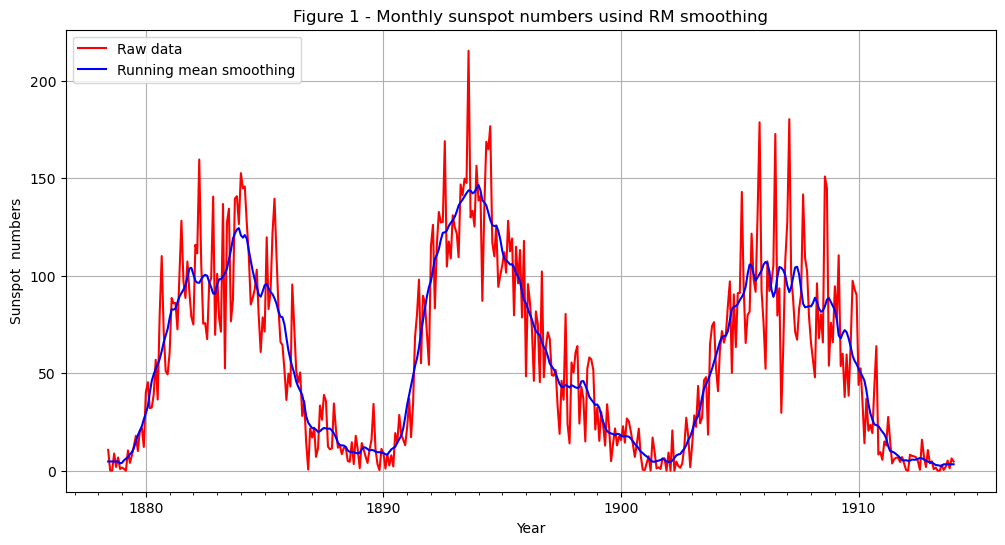

In [129]:
data_sol_mean=mean_13(data_sol)
plt.figure(figsize=(12,6))
plt.plot(dates, data_sol[:, 2], color='red',label='Raw data')
plt.plot(dates, data_sol_mean[:, 2],color='blue',label='Running mean smoothing')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(10))    
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))    
plt.legend(loc='upper left')
plt.title('Figure 1 - Monthly sunspot numbers usind RM smoothing')
plt.xlabel('Year')
plt.ylabel('Sunspot  numbers')
plt.grid()
plt.show()

3. Applying forward-backward exponential smoothing to the monthly mean sunspot numbers. Finding is
there a smoothing constant (𝛼) that yields better results compared to the 13-month
running mean based on deviation and variability indicators

Firstly, define deviation and variability indicators of 13-month running mean

In [130]:
# function calc_indicators calculates deviation and variability indicators

def calc_indicators(z, x):
    dev_ind = np.sum((z - x) ** 2)
    n = len(z)
    var_ind = 0
    for i in range(n-2):
        var_ind += (x[i + 2] - 2 * x[i + 1] + x[i]) ** 2
    return dev_ind, var_ind

In [131]:
dev_ind_mean, var_ind_mean = calc_indicators(data_sol[:, 2], data_sol_mean[:, 2])
print(f'Deviation indicator for running mean: {dev_ind_mean}')
print(f'Variability indicator for running mean: {var_ind_mean}')

Deviation indicator for running mean: 167671.32293402776
Variability indicator for running mean: 1307.4293402777782


Let's build a plot showing deviation and variability indicators depending on alpha for forward-backwars exponential smoothing. We will also plot the values of the indicators for the running mean in the form of horizontal lines on the plot.

In [132]:
# function find_exp finds exponential smoothed trajectory
def find_exp(z, al):
    n=len(z)
    x_exp=np.zeros(n)
    x_exp[0]=z[0]
    for i in range(1,n):
        x_exp[i]=x_exp[i-1]+al*(z[i]-x_exp[i-1])
    return x_exp

In [133]:
# function find_backward_exp finds backward exponential smoothed trajectory
def find_backward_exp(x_fwd, al):
    n = len(x_fwd)
    x_exp_back = np.zeros(n)
    x_exp_back[n-1] = x_fwd[n-1]
    for i in range(n-2, -1, -1):
        x_exp_back[i]=x_exp_back[i+1] + al * (x_fwd[i]-x_exp_back[i+1])
    return x_exp_back

Let's find alpha as the value at which both indicators are the smallest and less than the indicators of the running mean.

In [134]:
dev_ind_opt = dev_ind_mean
var_ind_opt = var_ind_mean
for al in np.arange(0, 1, 0.01):
    x_exp = find_exp(data_sol[:, 2], al)
    x_exp_back = find_backward_exp(x_exp, al)
    dev_ind, var_ind = calc_indicators(data_sol[:, 2], x_exp_back)
    if dev_ind < dev_ind_opt and var_ind < var_ind_opt:
        alpha_opt = al
print(f'Optimal smoothing coefficient for exponential smoothing: {alpha_opt}')

Optimal smoothing coefficient for exponential smoothing: 0.27


Applying the forwsard-backward exponential smoothing

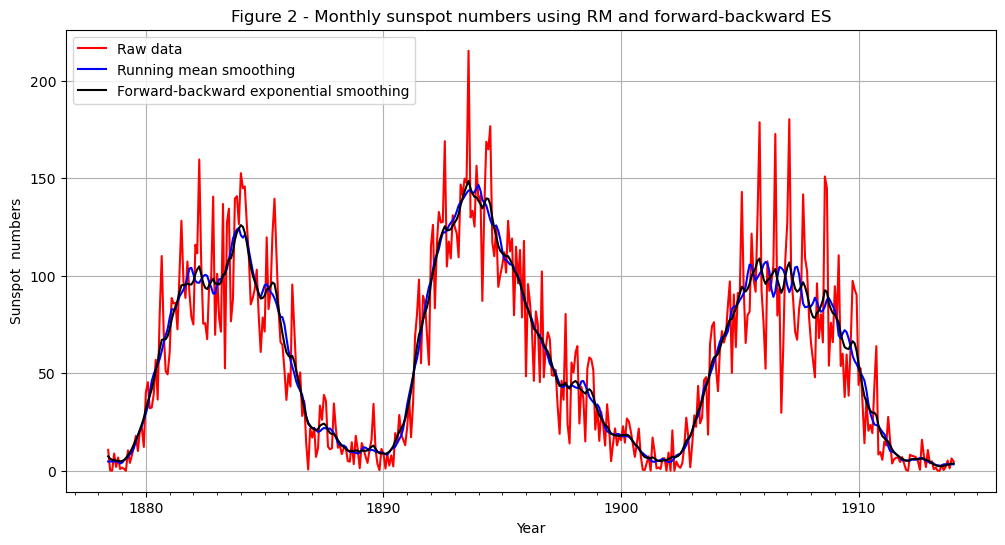

In [135]:
x_exp = find_exp(data_sol[:, 2], alpha_opt)
x_exp_back = find_backward_exp(x_exp, alpha_opt)
plt.figure(figsize=(12,6))
plt.plot(dates, data_sol[:, 2], color='red',label='Raw data')
plt.plot(dates, data_sol_mean[:, 2],color='blue',label='Running mean smoothing')
plt.plot(dates, x_exp_back, color='black', label='Forward-backward exponential smoothing')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(10))    
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))    
plt.legend(loc='upper left')
plt.title('Figure 2 - Monthly sunspot numbers using RM and forward-backward ES')
plt.xlabel('Year')
plt.ylabel('Sunspot  numbers')
plt.grid()
plt.show()

Let's find deviation and variability indicators

In [136]:
dev_ind_exp_back, var_ind_exp_back = calc_indicators(data_sol[:, 2], x_exp_back)
print(f'Deviation indicator for forward-backward exponential smoothing: {dev_ind_exp_back}')
print(f'Variability indicator for forward-backward exponential smoothing: {var_ind_exp_back}')

Deviation indicator for forward-backward exponential smoothing: 126847.90383174804
Variability indicator for forward-backward exponential smoothing: 1264.8893214104346


We found out that with an alpha = 0.27, we get a better result with forward-backward exponential smoothing than running mean based on deviation and variability indicators.

Conclusion: For these data, forward-backward exponential smoothing gives a curve closer to the measurements and at the same time smoother

### Part II - 3D Surface Reconstruction Under Noise

1. Loading the noisy and true 3D surfaces

In [137]:
noisy_surf=np.loadtxt("noisy_surface.txt")
true_surf = np.loadtxt("true_surface.txt")

2. Let's plot the true and noisy graph with a color scale

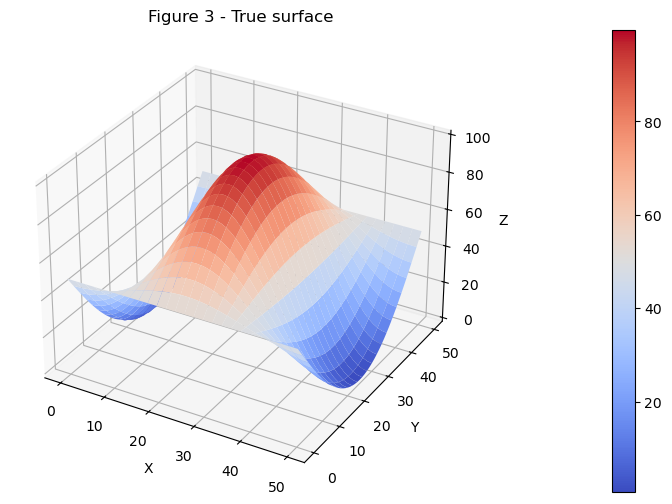

In [138]:
#Plot of true surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(true_surf.shape[1])
y = np.arange(true_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, true_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_title('Figure 3 - True surface')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

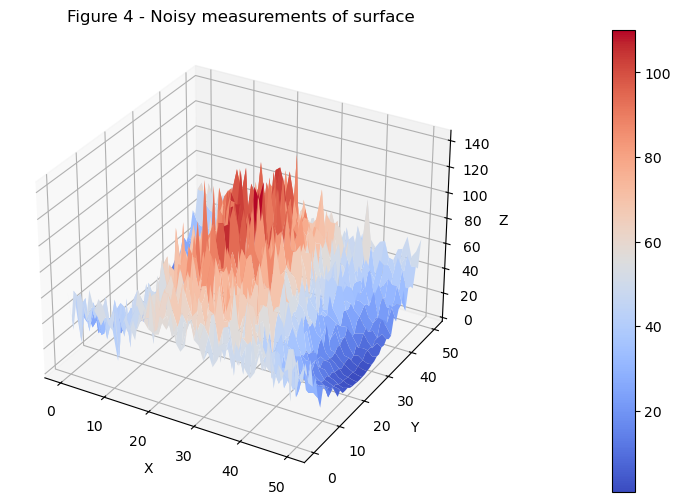

In [139]:
#Plot of noisy surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(noisy_surf.shape[1])
y = np.arange(noisy_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, noisy_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_title('Figure 4 - Noisy measurements of surface')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

3. Let's determine the variance of the deviation between the noisy surface and the true surface

In [140]:
#Transforming to line matrix
true_mat=true_surf.reshape(-1)
noisy_mat=noisy_surf.reshape(-1)

**Variance of the deviation between the noisy surface and the true surface**

$$\sigma^{2} = \frac{1}{N-1} \sum_{i=1}^{N} (ytrue_i - ynoise_i)^2$$

In [141]:
#Calculating the variance
n = len(true_mat)
var = 0
for i in range(0, n):
    var+=(1/(n-1))*(true_mat[i]-noisy_mat[i])**2
print(f'The variance of the deviation between the noisy surface and the true surface is equal: {var}')

The variance of the deviation between the noisy surface and the true surface is equal: 122.87308206873873


4. Let's apply forward-backward exponential smoothing filter using a smoothing constatnt=0.335

Step 1: Perform forward exponential smoothing on the rows

In [142]:
smooth_surf=np.zeros((true_surf.shape[0],true_surf.shape[1]))
for i in range(0, smooth_surf.shape[0]):
    smooth_surf[i,:]=find_exp(noisy_surf[i,:], 0.335)

Step 2: Perform backward exponential smoothing on the rows

In [143]:
for i in range(0, smooth_surf.shape[0]):
    smooth_surf[i,:]=find_backward_exp(smooth_surf[i,:], 0.335)

Step 3: Perform backward exponential smoothing on the columns

In [144]:
for i in range(0,smooth_surf.shape[1]):
    smooth_surf[:,i]=np.reshape(find_backward_exp(smooth_surf[:,i].reshape(-1),0.335),-1)

Step 4: Perform forward exponential smoothing on the columns

In [145]:
for i in range(0,smooth_surf.shape[1]):
    smooth_surf[:,i]=np.reshape(find_exp(smooth_surf[:,i].reshape(-1),0.335),-1)

5. Let's visualize filtering surface and compare with the true surface

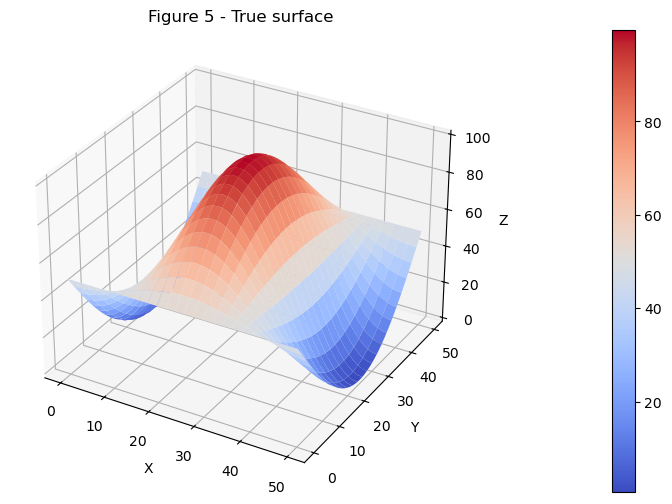

In [146]:
#Plot of true surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(true_surf.shape[1])
y = np.arange(true_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, true_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Figure 5 - True surface')
plt.show()

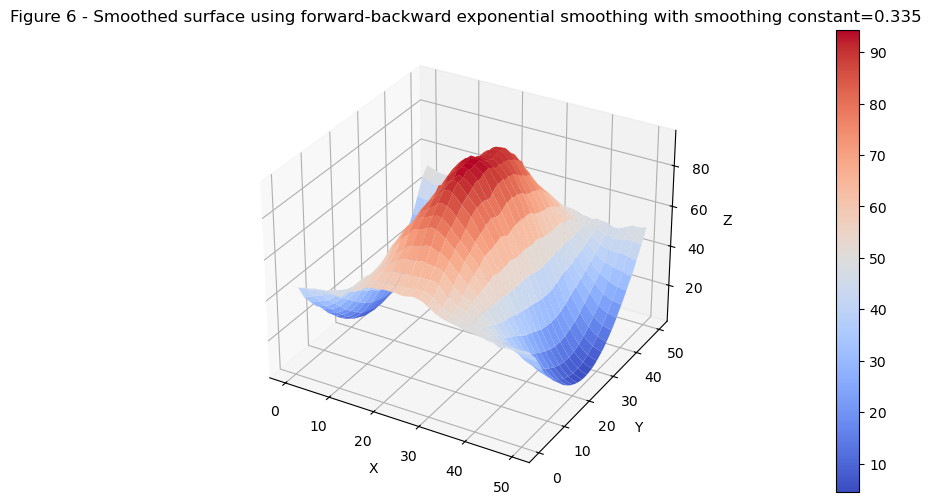

In [147]:
#Plot of smoothed surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(smooth_surf.shape[1])
y = np.arange(smooth_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, smooth_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Figure 6 - Smoothed surface using forward-backward exponential smoothing with smoothing constant=0.335')
plt.show()

Visually comparing both surfaces, we can conclude that applying an exponential filter smooths the noisy surface very well. Therefore, this filter is worth applying to smoothing 3D data. 

6. Let's determine the variance of the deviation between the smoothed surface and the true surface

In [148]:
#Transforming to line matrix
smooth_mat=smooth_surf.reshape(-1)

In [149]:
#Calculating the variance
n = len(true_mat)
var=0
for i in range(0,n):
    var+=(1/(n-1))*(true_mat[i]-smooth_mat[i])**2
print(f'The variance of the deviation between the smoothed surface and the true surface is equal: {var}')

The variance of the deviation between the smoothed surface and the true surface is equal: 7.923996447007125


As we can see, the variance of the deviation has been significantly reduced. Thus, this filter has effectively smoothed the data.

7. Let's try changing the smoothing factor to a larger and smaller one.

Case 1: smaller value

In [150]:
#Exponential smoothing
smooth_surf=np.zeros((true_surf.shape[0],true_surf.shape[1]))
for i in range(0,smooth_surf.shape[0]):
    smooth_surf[i,:]=find_exp(noisy_surf[i,:],0.135)
for i in range(0,smooth_surf.shape[0]):
    smooth_surf[i,:]=find_backward_exp(smooth_surf[i,:],0.135)
for i in range(0,smooth_surf.shape[1]):
    smooth_surf[:,i]=np.reshape(find_backward_exp(smooth_surf[:,i].reshape(-1),0.135),-1)
for i in range(0,smooth_surf.shape[1]):
    smooth_surf[:,i]=np.reshape(find_exp(smooth_surf[:,i].reshape(-1),0.135),-1)

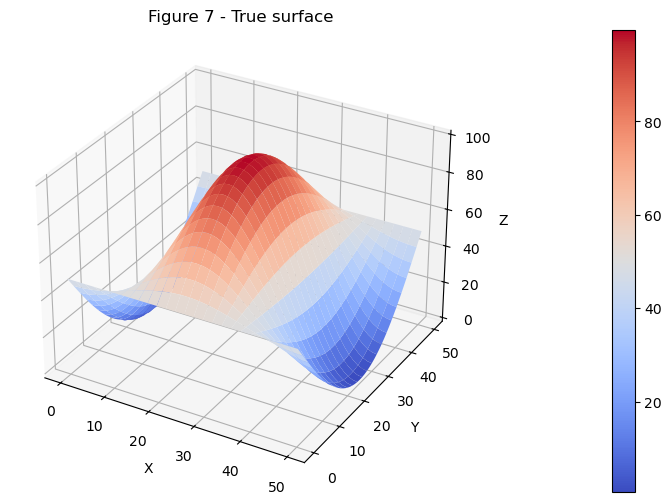

In [151]:
#Plot of true surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(true_surf.shape[1])
y = np.arange(true_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, true_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Figure 7 - True surface')
plt.show()

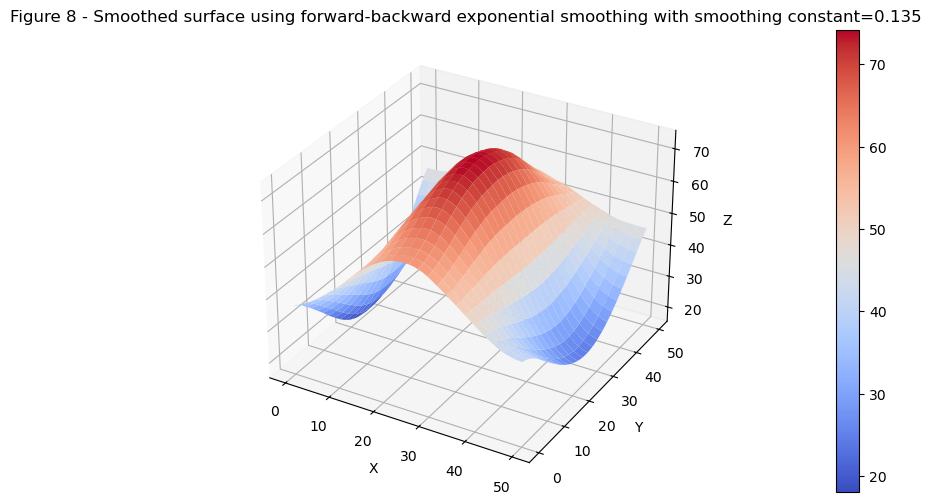

In [152]:
#Plot of smoothed surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(smooth_surf.shape[1])
y = np.arange(smooth_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, smooth_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Figure 8 - Smoothed surface using forward-backward exponential smoothing with smoothing constant=0.135')
plt.show()

In [153]:
#Transforming to line matrix
smooth_mat=smooth_surf.reshape(-1)

In [154]:
#Calculating the variance
n = len(true_mat)
var=0
for i in range(0,n):
    var+=(1/(n-1))*(true_mat[i]-smooth_mat[i])**2
print(f'The variance of the deviation between the smoothed surface and the true surface is equal: {var}')

The variance of the deviation between the smoothed surface and the true surface is equal: 133.9608258087131


As we can see, with a smaller smoothing coefficient, the values ​​appear smoother, but the reliability of the results is very different, which leads to completely different values ​​and an increase in dispersion.

Case 2: larger value

In [155]:
#Exponential smoothing
smooth_surf=np.zeros((true_surf.shape[0],true_surf.shape[1]))
for i in range(0,smooth_surf.shape[0]):
    smooth_surf[i,:]=find_exp(noisy_surf[i,:],0.635)
for i in range(0,smooth_surf.shape[0]):
    smooth_surf[i,:]=find_backward_exp(smooth_surf[i,:],0.635)
for i in range(0,smooth_surf.shape[1]):
    smooth_surf[:,i]=np.reshape(find_backward_exp(smooth_surf[:,i].reshape(-1),0.635),-1)
for i in range(0,smooth_surf.shape[1]):
    smooth_surf[:,i]=np.reshape(find_exp(smooth_surf[:,i].reshape(-1),0.635),-1)

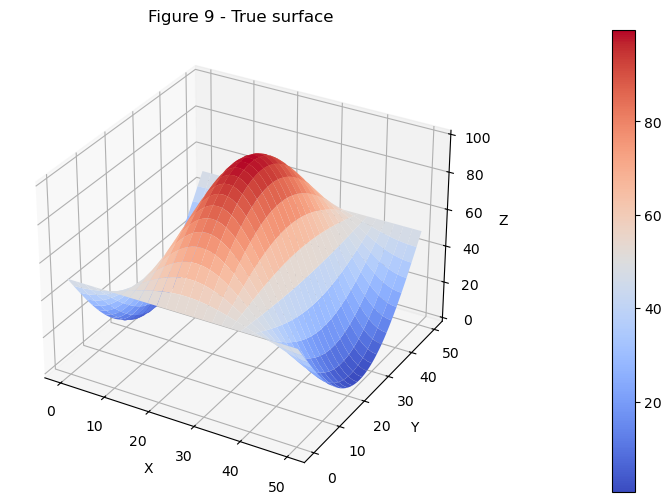

In [156]:
#Plot of true surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(true_surf.shape[1])
y = np.arange(true_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, true_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Figure 9 - True surface')
plt.show()

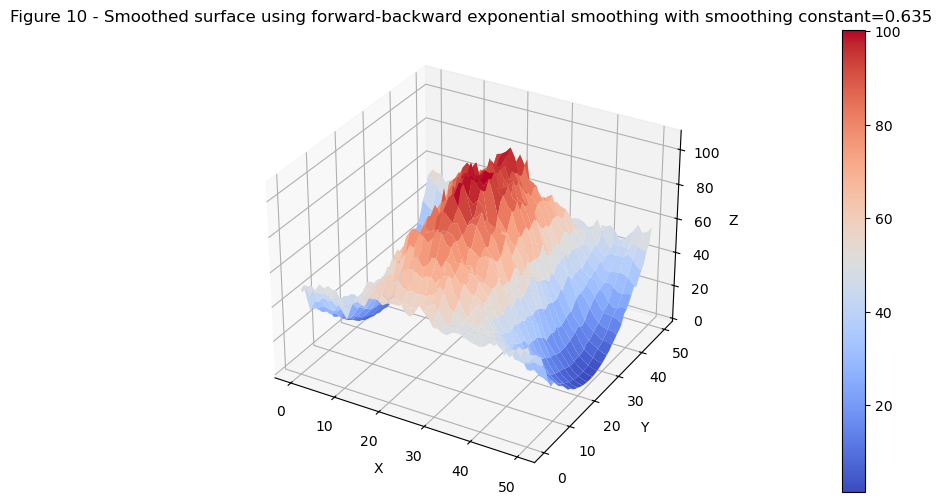

In [157]:
#Plot of smoothed surface with colorbar
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')
x = np.arange(smooth_surf.shape[1])
y = np.arange(smooth_surf.shape[0])
x, y = np.meshgrid(x, y)
surf = ax.plot_surface(x, y, smooth_surf, cmap=plt.cm.coolwarm)
fig.colorbar(surf, pad=0.15)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Figure 10 - Smoothed surface using forward-backward exponential smoothing with smoothing constant=0.635')
plt.show()

In [158]:
#Transforming to line matrix
smooth_mat=smooth_surf.reshape(-1)

In [159]:
#Calculating the variance
n = len(true_mat)
var=0
for i in range(0,n):
    var+=(1/(n-1))*(true_mat[i]-smooth_mat[i])**2
print(f'The variance of the deviation between the smoothed surface and the true surface is equal: {var}')

The variance of the deviation between the smoothed surface and the true surface is equal: 10.55785396258455


As we can see, with an increase in the coefficient, the dispersion is smaller, but the quality of filtering is significantly worse, the data are not smoothed well, which allows us to conclude that an increase in the coefficient leads to a deterioration in the quality of data smoothing.

**Conclusion:** 

Thus, we understand that the choice of the coefficient in the exponential smoothing method plays a key role in the final smoothing quality. This choice requires a thorough quality analysis. A smaller coefficient reduces the reliability of the original data, while a larger coefficient leads to poorer filtering quality.

**Learning log:**

What we learned:

We studied how the smoothing coefficient affects the quality of filtering and the reliability of data. We also learned more about working with data in three-dimensional space. It's not always possible to find the optimal smoothing coefficient that will produce a curve better than the moving average method. Sometimes it's possible to optimize for a single metric, sometimes for deviation and variability metrics.

What difficulties we faced:

We encountered difficulties in understanding surface visualization and choosing the right smoothing factor to find the sweet spot. Which criterion should optimize the smoothing factor: a balance between deviation and variability, or minimizing one or the other?